In [1]:
# init
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path
from skimage import exposure, filters
from skimage.color import rgb2gray
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_distances

bunny_original = mpimg.imread('DM Dataset\\Dog_cat_rabbit\\dataset\\Rabbit\\000027.jpg')
cat_original = mpimg.imread('DM Dataset\\Dog_cat_rabbit\\dataset\\Cat\\0008.jpg')
dog_original = mpimg.imread('DM Dataset\\Dog_cat_rabbit\\dataset\\Dog\\0017.jpg')

# convert to grayscale 2b
grayscale_arr = [rgb2gray(bunny_original), rgb2gray(cat_original), rgb2gray(dog_original)]

bunny_arr = []
cat_arr = []
dog_arr = []

bunny_folder = Path(r"DM Dataset\Dog_cat_rabbit\dataset\Rabbit")
cat_folder = Path(r"DM Dataset\Dog_cat_rabbit\dataset\Cat")
dog_folder = Path(r"DM Dataset\Dog_cat_rabbit\dataset\Dog")

for file_path in bunny_folder.iterdir():
    if file_path.is_file():
        bunny_arr.append(rgb2gray(mpimg.imread("DM Dataset\\Dog_cat_rabbit\\dataset\\Rabbit\\" + file_path.name)))

for file_path in cat_folder.iterdir():
    if file_path.is_file():
        cat_arr.append(rgb2gray(mpimg.imread("DM Dataset\\Dog_cat_rabbit\\dataset\\Cat\\" + file_path.name)[..., :3]))

for file_path in dog_folder.iterdir():
    if file_path.is_file():
        dog_arr.append(rgb2gray(mpimg.imread("DM Dataset\\Dog_cat_rabbit\\dataset\\Dog\\" + file_path.name)))



def angle(dx, dy):
    return np.mod(np.arctan2(dy, dx), np.pi)

print("finish init")

finish init


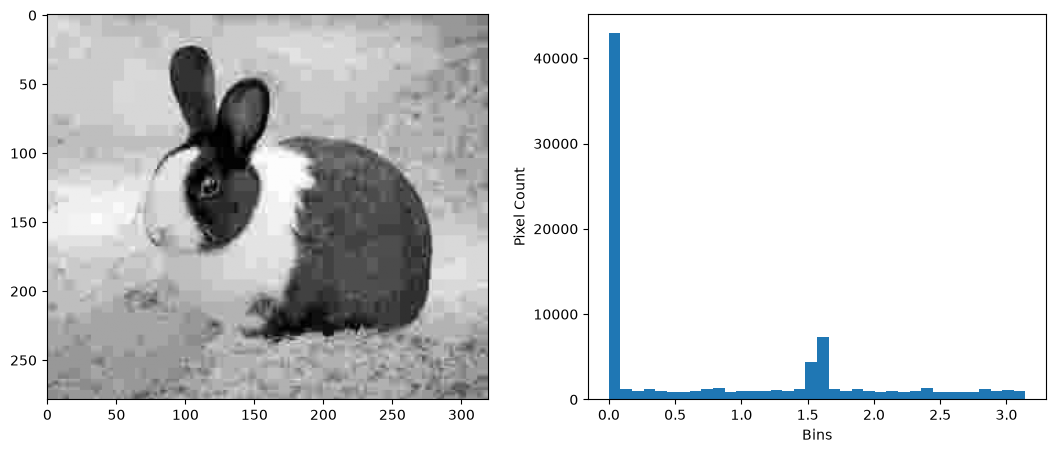

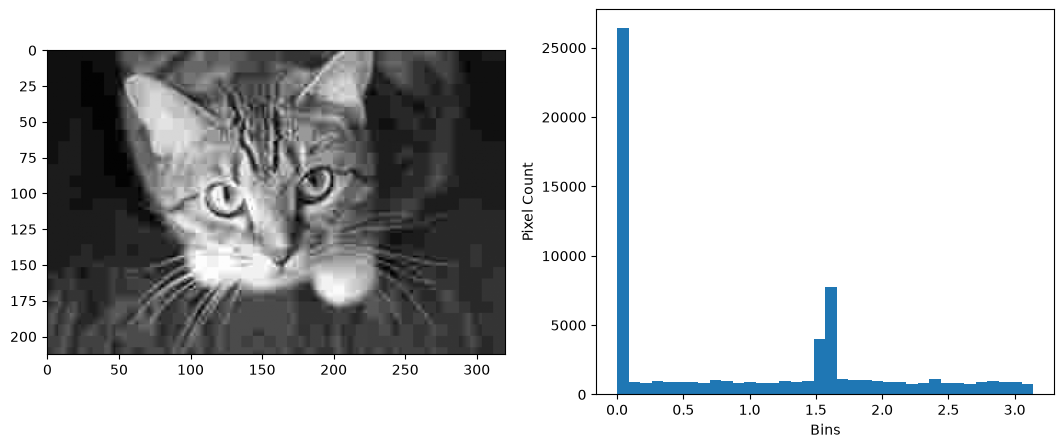

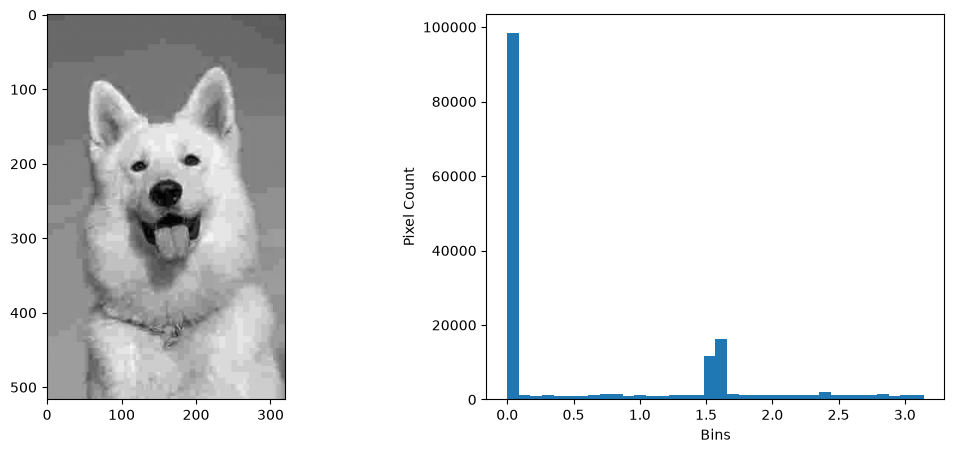

In [2]:
# edge diagram 2e
histogram_arr = []

for image in grayscale_arr:
    angle_sobel = angle(filters.sobel_h(image), filters.sobel_v(image))
    hist, bins = exposure.histogram(angle_sobel, nbins=36)
    histogram_arr.append(hist)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(image, cmap=plt.cm.gray)
    axes[1].bar(bins, hist, width=np.pi / 36)
    axes[1].set_xlabel('Bins')
    axes[1].set_ylabel('Pixel Count')
    plt.show()


In [3]:
# Compare Distances 2f
hist_arr_reshape_0 = histogram_arr[0].reshape(1, -1)
hist_arr_reshape_1 = histogram_arr[1].reshape(1, -1)

euc_dist = euclidean_distances(hist_arr_reshape_0, hist_arr_reshape_1)
man_dist = manhattan_distances(hist_arr_reshape_0, hist_arr_reshape_1)
cos_dist = cosine_distances(hist_arr_reshape_0, hist_arr_reshape_1)
print("Euclidean ", euc_dist)
print("Manhattan ", man_dist)
print("Cosine ", cos_dist)


Euclidean  [[16576.28426397]]
Manhattan  [[22144.]]
Cosine  [[0.00874218]]


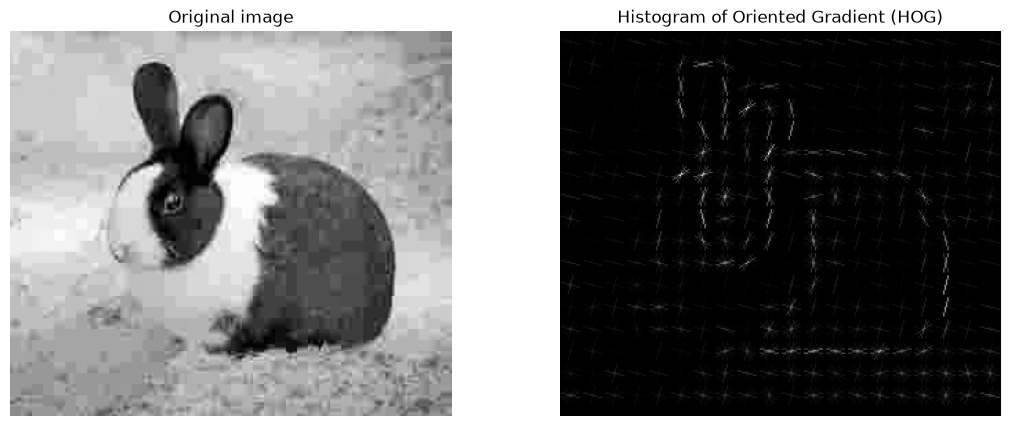

In [4]:
# HOG 3
fd, hog_image = hog(
    grayscale_arr[0],
    orientations=8,
    pixels_per_cell=(16, 16),
    cells_per_block=(1, 1),
    visualize=True,
)

hog_scaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
ax1.imshow(grayscale_arr[0], cmap=plt.cm.gray)
ax1.set_title('Original image')
ax2.imshow(hog_scaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradient (HOG)')
ax1.axis('off')
ax2.axis('off')
plt.show()

In [ ]:
# PCA
bunny_histogram_arr = []
cat_histogram_arr = []
dog_histogram_arr = []
# convert all images to histograms 4a-b
for image in bunny_arr:
    angle_sobel = angle(filters.sobel_h(image), filters.sobel_v(image))
    hist, bins = exposure.histogram(angle_sobel, nbins=36)
    bunny_histogram_arr.append(hist)

for image in cat_arr:
    angle_sobel = angle(filters.sobel_h(image), filters.sobel_v(image))
    hist, bins = exposure.histogram(angle_sobel, nbins=36)
    cat_histogram_arr.append(hist)

for image in dog_arr:
    angle_sobel = angle(filters.sobel_h(image), filters.sobel_v(image))
    hist, bins = exposure.histogram(angle_sobel, nbins=36)
    dog_histogram_arr.append(hist)

fig, ax = plt.subplots(1, figsize=(13, 5))

labels = np.array(
    ["Rabbit"] * len(bunny_histogram_arr) +
    ["Cat"] * len(cat_histogram_arr) +
    ["Dog"] * len(dog_histogram_arr)
)
    
aggregate_histogram = np.vstack([bunny_histogram_arr, cat_histogram_arr, dog_histogram_arr])

 
pca = PCA(n_components=2)
# reduce from 36 to 2 bins 4c
scaled_histogram =pca.fit_transform(aggregate_histogram)

# plot 4d
for animal, color in [
    ("Rabbit", "red"),
    ("Cat", "green"),
    ("Dog", "blue")
]:
    mask = labels == animal

    ax.scatter(
        scaled_histogram[mask, 0],
        scaled_histogram[mask, 1],
        c=color,
        label=animal,
        s=10
    )

ax.set_title("PCA")
ax.set_xlabel("First Component")
ax.set_ylabel("Second Component")

plt.legend()
plt.show()

print("There are no visually separable classes.")